In [ ]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import numpy as np
import trajectory_data
import matplotlib.pyplot as plt
from tqdm import tqdm
import cv2 as cv
import cv2
import numpy as np

In [ ]:
class 

In [5]:
set1 = np.load(trajectory_data.package_path+'/trajectories/peg_pick404.npz')['img']
set2 = np.load(trajectory_data.package_path+'/trajectories/peg_pick404_trial_0.npz')['img']
set_ = np.load(trajectory_data.package_path+'/trajectories/peg_pick404_trial_1.npz')['img']




In [8]:
list(np.load(trajectory_data.package_path+'/trajectories/peg_pick404.npz').keys())

['traj',
 'ori',
 'grip',
 'img',
 'img_feedback_flag',
 'spiral_flag',
 'risk_flag',
 'safe_flag',
 'novel_risk_flag',
 'novel_safe_flag']

In [2]:
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
#model2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
#model3 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitl14')

model.eval()

pre = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(256),
    # torchvision.transforms.Resize(256, interpolation=torchvision.transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),  
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
])

def embed(img_pil):
    x = pre(img_pil).unsqueeze(0)        # [1,3,224,224]
    with torch.no_grad():
        out = model.forward_features(x)  # implementation-specific
        # Option A: use CLS token
        feat = out["x_norm_clstoken"]   # [1, D]
        # Option B: mean-pool patch tokens (exclude cls/registers)
        # feat = out["x_norm_patchtokens"].mean(dim=1)  # [1, D]
    feat = F.normalize(feat, dim=-1)
    return feat.squeeze(0)               # [D]

def cosine_sim(a, b):
    return float((a*b).sum())  # a and b already L2-normalized


Using cache found in /home/petr/.cache/torch/hub/facebookresearch_dinov2_main
/home/petr/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/petr/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/petr/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


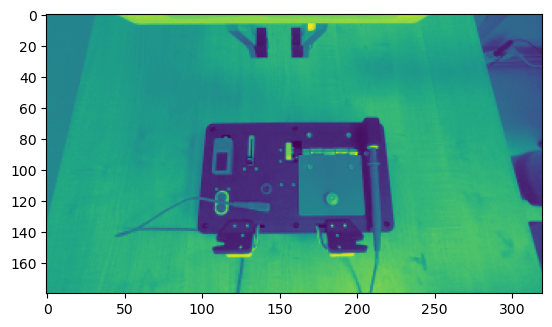

In [5]:
plt.imshow(set1[0])

In [13]:
def get_correlation(set1, set2):
    correlation = np.zeros((len(set1), len(set2)))
    emb1, emb2 = [], []
    for x in tqdm(range(len(set1))):
        f1 = embed(Image.fromarray(set1[x]))
        emb1.append(f1)
    for y in tqdm(range(len(set2))):
        f2 = embed(Image.fromarray(set2[y]))
        emb2.append(f2)
    for x in range(len(set1)):
        for y in range(len(set2)):
            score = cosine_sim(emb1[x], emb2[y])
            correlation[x,y] = score
    return correlation

In [14]:
c = get_correlation(set1, set2)

100%|██████████| 619/619 [00:41<00:00, 14.75it/s]


In [ ]:
%matplotlib qt
def super_plot(c, set1, set2):
    def onclick(event):
        if event.inaxes == ax:
            # round to nearest integer indices
            x = int(round(event.xdata))
            y = int(round(event.ydata))
            print(f"Clicked: x={x}, y={y}")

            # concatenate the chosen images horizontally
            if 0 <= x < len(set1) and 0 <= y < len(set2):
                combined = np.concatenate((set1[x], set2[y]), axis=1)

                # open a new figure to show concatenation
                plt.figure()
                plt.imshow(combined, cmap="gray")
                plt.title(f"Concatenated Image1[{x}] + Image2[{y}]")
                plt.axis("off")
                plt.show()

    fig, ax = plt.subplots()
    heatmap = ax.imshow(c, cmap="hot", interpolation="nearest")
    plt.colorbar(heatmap)
    y, x = np.where(c > 0.9)
    plt.scatter(x, y, facecolors='none', edgecolors='green', s=1, linewidths=0.1)

    cid = fig.canvas.mpl_connect("button_press_event", onclick)
    plt.show()

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in ""


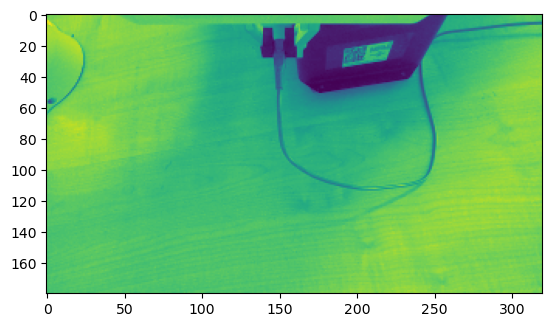

In [ ]:
plt.imshow(set1[500])

In [62]:
def play_video(frames):
    fps = 30
    delay = max(1, int(1000 / fps))  # milliseconds
    for f in frames:
        # if float frames in [0,1], convert:
        # f = (np.clip(f, 0, 1) * 255).astype('uint8')
        cv.imshow('video', f)
        if cv.waitKey(delay) & 0xFF == 27:  # ESC to quit
            break
    cv.destroyAllWindows()

In [65]:
play_video(np.load(trajectory_data.package_path+'/trajectories/peg_pick404_trial_1.npz')['img'])

In [ ]:
peg_pick3 = np.load(trajectory_data.package_path+'/trajectories/peg_pick404_trial_1.npz')

In [29]:
%%time
e_test = embed(Image.fromarray(set1[0]))

CPU times: user 2.71 s, sys: 2.98 ms, total: 2.71 s
Wall time: 389 ms


In [133]:
class SceneMatcher:
    def __init__(self, method="ORB", max_side=800, nfeatures=2000, ratio=0.75,
                 homography=True, ransac_thresh=3.0, maxIters=1000, confidence=0.99):
        self.method = method.upper()
        self.max_side = max_side
        self.ratio = ratio
        self.use_H = homography
        self.ransac_thresh = ransac_thresh
        self.maxIters = maxIters
        self.confidence = confidence

        if self.method == "SIFT":
            self.feat = cv2.SIFT_create(nfeatures=nfeatures)
            # FLANN KD-Tree for float descriptors
            index_params = dict(algorithm=1, trees=4)  # FLANN_INDEX_KDTREE = 1
            search_params = dict(checks=32)
            self.matcher = cv2.FlannBasedMatcher(index_params, search_params)
            self.norm = cv2.NORM_L2
        elif self.method == "AKAZE":
            self.feat = cv2.AKAZE_create()  # descriptor is binary by default (MLDB)
            # FLANN LSH for binary descriptors
            index_params = dict(algorithm=6,  # FLANN_INDEX_LSH
                                table_number=12, key_size=20, multi_probe_level=2)
            search_params = dict(checks=64)
            self.matcher = cv2.FlannBasedMatcher(index_params, search_params)
            self.norm = cv2.NORM_HAMMING
        else:  # ORB
            self.feat = cv2.ORB_create(nfeatures=nfeatures, fastThreshold=15, scaleFactor=1.2, nlevels=8)
            index_params = dict(algorithm=6,  # FLANN_INDEX_LSH
                                table_number=12, key_size=20, multi_probe_level=2)
            search_params = dict(checks=64)
            self.matcher = cv2.FlannBasedMatcher(index_params, search_params)
            self.norm = cv2.NORM_HAMMING

        # Pick the best available robust method
        self._usac = getattr(cv2, "USAC_FAST", None)
        self._magsac = getattr(cv2, "USAC_MAGSAC", None)

    def _prep(self, img):
        # to grayscale + downscale, preserving aspect ratio
        if img.ndim == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        h, w = img.shape[:2]
        s = self.max_side / max(h, w)
        if s < 1.0:
            img = cv2.resize(img, (int(w*s), int(h*s)), interpolation=cv2.INTER_AREA)
        return img

    def similar_scene(self, img1, img2, min_good=8):
        img1 = self._prep(img1)
        img2 = self._prep(img2)

        k1, d1 = self.feat.detectAndCompute(img1, None)
        k2, d2 = self.feat.detectAndCompute(img2, None)
        if d1 is None or d2 is None or len(k1) < min_good or len(k2) < min_good:
            return 0.0, None

        # FLANN + KNN
        knn = self.matcher.knnMatch(d1, d2, k=2)
        # Lowe ratio
        good = []
        for pair in knn:
            if len(pair) < 2:
                continue
            m, n = pair
            if m.distance < self.ratio * n.distance:
                good.append(m)

        if len(good) < min_good:
            return 0.0, None

        pts1 = np.float32([k1[m.queryIdx].pt for m in good])
        pts2 = np.float32([k2[m.trainIdx].pt for m in good])

        # Robust geometry
        mask = None
        if self.use_H:
            method = cv2.RANSAC
            if self._usac is not None:   # prefer USAC if available
                method = self._usac
            elif self._magsac is not None:
                method = self._magsac

            H, inliers = cv2.findHomography(
                pts1, pts2, method,
                ransacReprojThreshold=self.ransac_thresh,
                maxIters=self.maxIters, confidence=self.confidence
            )
            mask = inliers
            M = H
        else:
            method = getattr(cv2, "USAC_FAST", cv2.RANSAC)
            F, inliers = cv2.findFundamentalMat(
                pts1, pts2, method, ransacReprojThreshold=self.ransac_thresh,
                confidence=self.confidence, maxIters=self.maxIters
            )
            mask = inliers
            M = F

        inlier_ratio = float(mask.sum()) / len(good) if mask is not None else 0.0
        return inlier_ratio, M
sm = SceneMatcher()

In [ ]:
def similar_scene(img1, img2, method="ORB"):
    if method == "SIFT":
        feat = cv2.SIFT_create()
        norm = cv2.NORM_L2
    else:  # ORB is free + fast
        feat = cv2.ORB_create(nfeatures=4000)
        norm = cv2.NORM_HAMMING

    k1, d1 = feat.detectAndCompute(img1, None)
    k2, d2 = feat.detectAndCompute(img2, None)
    if d1 is None or d2 is None: return 0.0, None

    matcher = cv2.BFMatcher(norm, crossCheck=False)
    knn = matcher.knnMatch(d1, d2, k=2)

    # Lowe’s ratio test
    good = [m for m, n in knn if m.distance < 0.75 * n.distance]
    if len(good) < 8: return 0.0, None

    pts1 = np.float32([k1[m.queryIdx].pt for m in good])
    pts2 = np.float32([k2[m.trainIdx].pt for m in good])

    H, inliers = cv2.findHomography(pts1, pts2, cv2.RANSAC, ransacReprojThreshold=3.0)
    inlier_ratio = float(inliers.sum()) / len(good) if inliers is not None else 0.0
    return inlier_ratio, H

In [100]:
import os, glob, numpy as np, torch
from torch.utils.data import Dataset, DataLoader

# ---- tiny dict-like wrappers ----
class TimestepView(dict):
    """One rollout @ a single timestep with a convenience .image (H,W) uint8."""
    @property
    def image(self):
        img = self.get('img', None)  # (1,H,W) float32 in [0,1]
        if img is None: return None
        arr = img.squeeze(0).detach().cpu().numpy()
        return (arr * 255).astype(np.uint8)

class BatchTimestepView(dict):
    """Batch across multiple rollouts @ same timestep with quick image helpers."""
    def images_uint8(self):
        """Return numpy stack (B,H,W) uint8, or None if no images."""
        imgs = self.get('img', None)  # (B,1,H,W) float32 in [0,1]
        if imgs is None: return None
        arr = imgs.squeeze(1).detach().cpu().numpy()
        return (arr * 255).astype(np.uint8)
    def strip_uint8(self):
        """Horizontal strip (H, sum W) uint8 for quick side-by-side viewing."""
        arr = self.images_uint8()
        if arr is None: return None
        return np.concatenate([a for a in arr], axis=1)

# ---- dataset ----
class TrajectoryDataset(Dataset):
    """
    Each item is one rollout (skill) loaded from a .npz file.
    Expected keys: ['traj','ori','grip','img','img_feedback_flag',
                    'spiral_flag','risk_flag','safe_flag',
                    'novel_risk_flag','novel_safe_flag']
    """
    default_keys = ['traj','ori','grip','img',
                    'img_feedback_flag','spiral_flag','risk_flag',
                    'safe_flag','novel_risk_flag','novel_safe_flag']

    def __init__(self, package_path, keys=None):
        self.dir = os.path.join(package_path, "trajectories")
        self.files = sorted(glob.glob(os.path.join(self.dir, "*.npz")))
        if not self.files:
            raise FileNotFoundError(f"No .npz files found in {self.dir}")
        self.keys = keys or self.default_keys

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        # lazy, low-RAM reads
        data = np.load(self.files[idx], allow_pickle=False, mmap_mode='r')
        out = {}
        for k in self.keys:
            if k not in data: 
                continue
            v = data[k]
            if k == 'img':            # (T,H,W) -> torch.float32 (T,1,H,W) in [0,1]
                v = torch.from_numpy(v).float()
                if v.ndim == 3: v = v[:, None, :, :]
                v = v / 255.0
            else:
                v = torch.from_numpy(np.asarray(v).T)
            out[k] = v
        out['name'] = os.path.splitext(os.path.basename(self.files[idx]))[0]
        out['length'] = out['traj'].shape[0] if 'traj' in out else None
        return out

    # ---- quick access helpers ----
    def timestep(self, idx, t):
        """
        Return TimestepView with tensors for a single timestep t from rollout idx.
        Adds .image property -> uint8 (H,W).
        """
        data = self[idx]
        # infer sequence length T from the time-major tensors
        time_tensors = [v for k,v in data.items() if k not in ('name','length') and torch.is_tensor(v) and v.ndim>0]
        T = data['length'] or min(v.shape[0] for v in time_tensors)
        t = int(max(0, min(t, T-1)))

        one = {}
        for k, v in data.items():
            if k in ('name','length'): continue
            one[k] = v[t] if (torch.is_tensor(v) and v.dim()>0 and v.size(0)==T) else v
        one['name'] = data['name']; one['t'] = t
        return TimestepView(one)

    def batch_timestep(self, indices, t):
        """
        Stack a batch at timestep t across multiple rollouts.
        Returns BatchTimestepView with tensors (e.g., img -> (B,1,H,W)) and:
          - .images_uint8() -> (B,H,W) uint8
          - .strip_uint8()  -> (H, sum W) uint8
        """
        buckets = {}
        names = []
        for i in indices:
            ts = self.timestep(i, t)
            names.append(ts['name'])
            for k, v in ts.items():
                if k in ('name','t'): continue
                buckets.setdefault(k, []).append(v if v.ndim else v.unsqueeze(0))
        stacked = {k: torch.stack([x if x.ndim>0 else x.unsqueeze(0) for x in lst], dim=0)
                   for k, lst in buckets.items()}
        stacked['names'] = names
        stacked['t'] = int(t)
        return BatchTimestepView(stacked)

    def side_by_side_images(self, indices, t):
        """Torch tensor (1,H,W_total) float32 in [0,1], concatenated horizontally."""
        ims = [self.timestep(i, t).get('img') for i in indices]
        ims = [im for im in ims if im is not None]
        if not ims: return None
        return torch.cat(ims, dim=-1)

In [101]:
dataset = TrajectoryDataset(trajectory_data.package_path)
ts = dataset.timestep(idx=0, t=10)

In [111]:
img_uint8 = ts.image                      # -> (H,W) uint8
img_uint8.shape

(180, 320)

In [112]:
batch = dataset.batch_timestep([0,1,2], t=10)

In [113]:
imgs_uint8 = batch.images_uint8()         # -> (B,H,W) uint8
imgs_uint8.shape

(3, 180, 320)

In [114]:
strip_uint8 = batch.strip_uint8()         # -> (H, sum W) uint8 (side-by-side)
strip_uint8.shape

(180, 960)

In [115]:
# Grab one skill at timestep t:
sample_t = dataset.timestep(idx=0, t=10)   # sample_t['img'] -> (1,H,W), sample_t['traj'] -> (D,)

In [116]:
# Grab a batch across multiple skills at timestep t (handy for comparisons):
batch_t = dataset.batch_timestep(indices=[0,1,2], t=10)
imgs = batch_t['img']                      # (B,1,H,W)
trajs = batch_t['traj']                    # (B,D)

In [117]:
# Make a simple side-by-side strip of images for visual diffing:
strip = dataset.side_by_side_images(indices=[0,1], t=10)  # (1,H,W1+W2)
strip.shape

torch.Size([1, 180, 640])

(1.0,
 array([[ 1.00000000e+00,  8.50111961e-15, -3.10190733e-13],
        [-1.35106530e-15,  1.00000000e+00,  9.73400675e-15],
        [-1.13019134e-17,  4.37918623e-17,  1.00000000e+00]]))

In [155]:
%%time
correlations = np.zeros((dataset[0]['length'], dataset[1]['length']))

set1 = [dataset.timestep(idx=0, t=i).image for i in range(dataset[0]['length'])]
set2 = [dataset.timestep(idx=1, t=i).image for i in range(dataset[1]['length'])]

for i in tqdm(range(dataset[0]['length'])):
    for j in range(dataset[1]['length']):
        a, b = sm.similar_scene(set1[i], set2[j])
        correlations[i,j] = a

100%|██████████| 767/767 [1:14:31<00:00,  5.83s/it]

CPU times: user 1h 21min 1s, sys: 9min 16s, total: 1h 30min 18s
Wall time: 1h 17min 18s


In [141]:
%%time
img1 = dataset.timestep(idx=0, t=i).image
img2 = dataset.timestep(idx=1, t=j).image

CPU times: user 423 ms, sys: 507 ms, total: 931 ms
Wall time: 187 ms


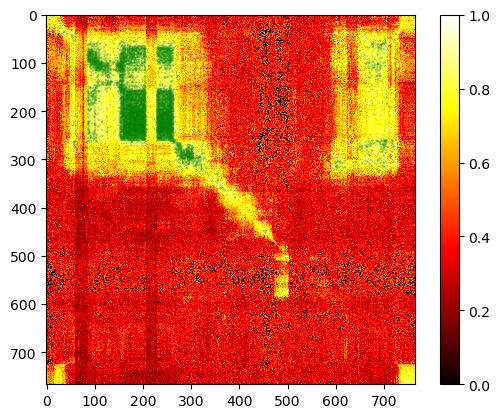

In [157]:
%matplotlib inline
super_plot(correlations, dataset[0], dataset[1])